In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [2]:
mnist_dataset = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
(x_train, y_train), (x_test, x_test) = mnist_dataset
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
set(y_train)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

In [6]:
classes = """0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot
""".splitlines()
classes = [line.split(': ')[1] for line in classes]
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
CLASSES = ['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

/tmp/ipykernel_285/121563604.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


Text(0.5, 1.0, 'Sneaker')

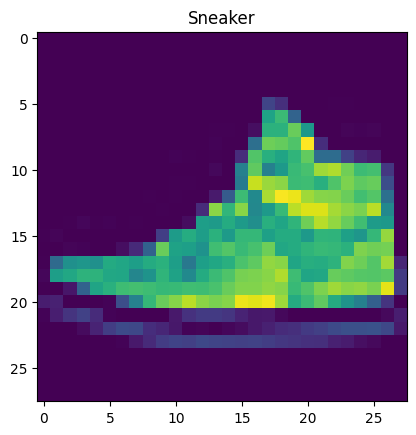

In [14]:
RANDOM_INDEX = np.random.randint(0, len(x_train))
plt.imshow(x_train[RANDOM_INDEX]);
plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


/tmp/ipykernel_285/121563604.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


Text(0.5, 1.0, 'Bag')

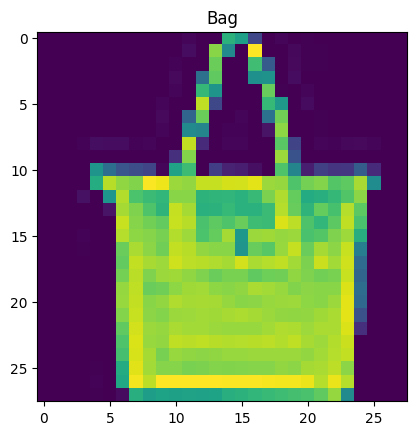

In [15]:
RANDOM_INDEX = np.random.randint(0, len(x_train))
plt.imshow(x_train[RANDOM_INDEX]);
plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


/tmp/ipykernel_285/121563604.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


Text(0.5, 1.0, 'Bag')

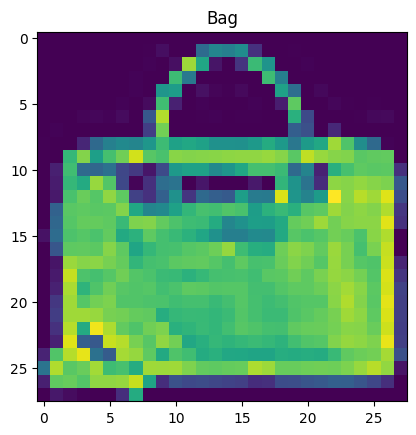

In [16]:
RANDOM_INDEX = np.random.randint(0, len(x_train))
plt.imshow(x_train[RANDOM_INDEX]);
plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


In [19]:
x_train[RANDOM_INDEX].min(), x_train[RANDOM_INDEX].max()

(np.uint8(0), np.uint8(255))

/tmp/ipykernel_285/4208120076.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


Text(0.5, 1.0, 'Bag')

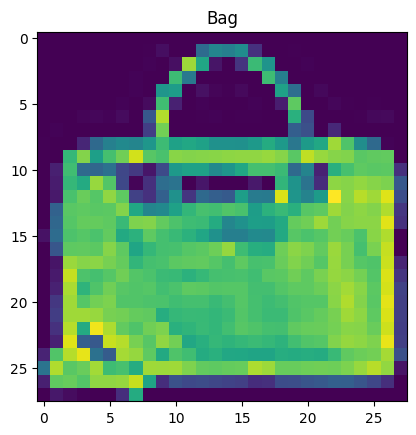

In [20]:
plt.imshow(x_train[RANDOM_INDEX] / 255);
plt.title(CLASSES[int(y_train[[RANDOM_INDEX]])])


In [28]:
achitectura_le_net5 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    ## LAYER DE Rescalare  - > imaginea de la 0..255 devine 0..1
    tf.keras.layers.Rescaling(scale=1./255),


    ## Functie de activa -> relu. Initial s-a inceput cu tanh
    tf.keras.layers.Conv2D(filters=32, kernel_size=(5, 5), activation='tanh'),
    tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2)),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(5, 5), activation='tanh'),
    tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=(2,2)),

    ### FULLY CONNECTED LAYERS
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=120, activation='tanh'),

    ## 10 categorii, functia de activa este softmax
    tf.keras.layers.Dense(units=10, activation='softmax'),

])


achitectura_le_net5.compile(optimizer=tf.keras.optimizers.SGD(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [29]:
achitectura_cnn_imbunatatita = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    ## LAYER DE Rescalare  - > imaginea de la 0..255 devine 0..1
    tf.keras.layers.Rescaling(scale=1./255),


    ## Functie de activa -> relu. Initial s-a inceput cu tanh
    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),


     ### FULLY CONNECTED LAYERS
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=120, activation='relu'),

     ## 10 categorii, functia de activa este softmax
    tf.keras.layers.Dense(units=10, activation='softmax'),

])


achitectura_cnn_imbunatatita.compile(optimizer=tf.keras.optimizers.Adam(), loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [30]:
achitectura_le_net5.fit(x_train, y_train, epochs=10)
achitectura_cnn_imbunatatita.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 27ms/step - accuracy: 0.7123 - loss: 0.8234
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.7924 - loss: 0.5623
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.8166 - loss: 0.5012
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.8306 - loss: 0.4640
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.8424 - loss: 0.4380
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8493 - loss: 0.4178
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.8548 - loss: 0.4023
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.8603 - loss: 0.3883
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.8636 - loss: 0.3760
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 26ms/step - accuracy: 0.8684 - loss: 0.3663
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.8209 - loss: 0.4903
Epoch 2/1